# Milestone 3 — Baseline Model Development
## Loan Default Prediction · Logistic Regression Baseline

---
## Cell 1 — Imports & global config

In [5]:
import gc
import os
import pickle
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")

# ── Global constants ──────────────────────────────────────────
DB_PATH     = "loans.db"      # SQLite database from EDA / DataPreprocessing notebooks
TABLE_NAME  = "loans"        
TARGET_COL  = "Status"
MODEL_PATH  = "lr_baseline.pkl"
RANDOM_SEED = 42

print("Imports OK")
print(f"  sklearn {__import__('sklearn').__version__}  |  "
      f"pandas {pd.__version__}  |  numpy {np.__version__}")
# ── Leakage columns to drop before any modelling ─────────────
# These features are recorded after loan outcome is known, or
# are proxies for the target — they cause artificially perfect scores.
LEAKAGE_COLS = [
    "Upfront_charges",        # often $0 for incomplete/defaulted loans
    "log_Upfront_charges",    # derived from above
    "Interest_rate_spread",   # missing/zero for defaulted loans
]
print(f"  Leakage columns flagged for removal: {LEAKAGE_COLS}")


Imports OK
  sklearn 1.8.0  |  pandas 2.3.3  |  numpy 2.3.5
  Leakage columns flagged for removal: ['Upfront_charges', 'log_Upfront_charges', 'Interest_rate_spread']


## Cell 2b — Leakage Guard

Drop leakage columns **immediately after loading**, before any feature engineering.


---
## Cell 2 — Memory-safe data load from SQLite

Reads directly from `loans.db` in configurable chunks.  
Each chunk is type-coerced and downcast **before** being appended — peak RAM stays minimal.

In [8]:
def load_from_sqlite(db_path: str, table: str, chunksize: int = 50_000) -> pd.DataFrame:
    """
    Stream a SQLite table in chunks, coerce types, downcast floats/ints,
    then concat. Keeps peak RAM well below a full-load read.
    """
    conn   = sqlite3.connect(db_path)
    query  = f"SELECT * FROM {table}"
    chunks = []

    for chunk in pd.read_sql_query(query, conn, chunksize=chunksize):

        # Fix SQLite bool-string serialisation ('True'/'False' -> 1/0)
        for col in chunk.select_dtypes("object").columns:
            uniq = set(chunk[col].dropna().unique())
            if uniq <= {"True", "False"}:
                chunk[col] = chunk[col].map({"True": 1, "False": 0})

        # Coerce remaining object columns to numeric; unparseable -> NaN
        for col in chunk.select_dtypes("object").columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

        # Downcast to save ~50% RAM
        for col in chunk.select_dtypes("float64").columns:
            chunk[col] = chunk[col].astype("float32")
        for col in chunk.select_dtypes("int64").columns:
            chunk[col] = chunk[col].astype("int32")

        chunks.append(chunk)

    conn.close()
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df


df = load_from_sqlite(DB_PATH, TABLE_NAME)

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Shape         : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory usage  : {mem_mb:.1f} MB")
print(f"Default rate  : {df[TARGET_COL].mean()*100:.2f} %")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Shape         : 148,669 rows  x  48 columns
Memory usage  : 27.2 MB
Default rate  : 24.64 %
Missing values: 0


,loan_limit,approv_in_adv,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,...,Region_central,Region_south,loan_to_income,high_LTV_flag,very_high_LTV_flag,low_credit_flag,very_low_credit_flag,high_dti_flag,high_interest_flag,risk_interaction
0,0,0,1,0,0,11.665655,3.99,0.3904,2596.449951,360.0,...,0,1,1.563297,1,0,0,0,0,0,0
1,0,0,1,0,1,12.238061,3.99,0.3904,2596.449951,360.0,...,0,0,1.437508,0,0,1,1,0,0,0
2,0,1,1,0,0,12.915341,4.56,0.2000,595.000000,360.0,...,0,1,1.410427,0,0,0,0,1,0,0


In [9]:
# ── Drop leakage columns ─────────────────────────────────────
cols_to_drop = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped {len(cols_to_drop)} leakage column(s): {cols_to_drop}")
print(f"Remaining columns : {df.shape[1]}  (including target)")

still_present = [c for c in LEAKAGE_COLS if c in df.columns]
if still_present:
    print(f"WARNING: {still_present} still present!")
else:
    print("✓ All leakage columns removed.")


Dropped 2 leakage column(s): ['Upfront_charges', 'Interest_rate_spread']
Remaining columns : 46  (including target)
✓ All leakage columns removed.


---
## Cell 3 — Feature Engineering Pipeline

Builds on what `DataPreprocessing.ipynb` already created.  
Every feature is guarded — no duplication, no KeyError on re-runs.

In [11]:
def safe_add(df: pd.DataFrame, col: str, values, note: str = "") -> None:
    """Add a column only if it does not already exist."""
    if col not in df.columns:
        df[col] = values
        tag = "[NEW] "
    else:
        tag = "[SKIP]"
    print(f"  {tag} {col}" + (f"  --  {note}" if note else ""))


print("=" * 58)
print(" FEATURE ENGINEERING")
print("=" * 58)

# ── A. Binary Risk Flags ─────────────────────────────────────
print("\n[A] Risk Flags")
safe_add(df, "high_LTV_flag",
         (df["LTV"] > 90).astype("int32"),
         "LTV > 90 %")
safe_add(df, "low_credit_flag",
         (df["Credit_Score"] < 650).astype("int32"),
         "sub-prime threshold")
safe_add(df, "high_dti_flag",
         (df["dtir1"] > 45).astype("int32"),
         "over-leveraged DTI")

# ── B. Interaction / Compound Risk Terms ─────────────────────
print("\n[B] Interaction Terms")
safe_add(df, "risk_interaction",
         df["low_credit_flag"] * df["high_LTV_flag"],
         "bad credit x high LTV")
safe_add(df, "credit_dti_risk",
         df["low_credit_flag"] * df["high_dti_flag"],
         "bad credit x high DTI")
safe_add(df, "ltv_dti_risk",
         df["high_LTV_flag"] * df["high_dti_flag"],
         "high LTV x high DTI")
safe_add(df, "triple_risk_flag",
         ((df["low_credit_flag"] + df["high_LTV_flag"] + df["high_dti_flag"]) == 3).astype("int32"),
         "all three flags at once")

# ── C. Ratio Features ────────────────────────────────────────
print("\n[C] Ratio Features")
# income & loan_amount already log-transformed in DataPreprocessing.ipynb
safe_add(df, "loan_to_income",
         np.where(
             df["income"] > 0,
             df["loan_amount"].astype("float32") / df["income"].astype("float32"),
             np.nan
         ).astype("float32"),
         "loan_amount / income (log-scaled)")

# ── D. Log Transforms ────────────────────────────────────────
print("[D] Log Transforms")
# log_Upfront_charges intentionally NOT created — Upfront_charges is a leakage column
print("  [SKIP] log_Upfront_charges  -- EXCLUDED: derived from leakage column")

# ── E. Ordinal Buckets ───────────────────────────────────────
print("\n[E] Ordinal Buckets")
safe_add(df, "credit_bucket",
         pd.cut(df["Credit_Score"],
                bins=[0, 580, 669, 739, 799, 900],
                labels=[0, 1, 2, 3, 4]).astype("float32"),
         "Poor/Fair/Good/VeryGood/Exceptional")
safe_add(df, "ltv_bucket",
         pd.cut(df["LTV"],
                bins=[0, 60, 80, 90, 100, 200],
                labels=[0, 1, 2, 3, 4]).astype("float32"),
         "LTV risk tier 0-4")

# ── F. Final Cleanup ─────────────────────────────────────────
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Column-by-column median fill - memory efficient
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

gc.collect()
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nFinal shape    : {df.shape}")
print(f"Memory usage   : {mem_mb:.1f} MB")
print(f"Missing values : {df.isnull().sum().sum()}")

 FEATURE ENGINEERING

[A] Risk Flags
  [SKIP] high_LTV_flag  --  LTV > 90 %
  [SKIP] low_credit_flag  --  sub-prime threshold
  [SKIP] high_dti_flag  --  over-leveraged DTI

[B] Interaction Terms
  [SKIP] risk_interaction  --  bad credit x high LTV
  [NEW]  credit_dti_risk  --  bad credit x high DTI
  [NEW]  ltv_dti_risk  --  high LTV x high DTI
  [NEW]  triple_risk_flag  --  all three flags at once

[C] Ratio Features
  [SKIP] loan_to_income  --  loan_amount / income (log-scaled)
[D] Log Transforms
  [SKIP] log_Upfront_charges  -- EXCLUDED: derived from leakage column

[E] Ordinal Buckets
  [NEW]  credit_bucket  --  Poor/Fair/Good/VeryGood/Exceptional
  [NEW]  ltv_bucket  --  LTV risk tier 0-4

Final shape    : (148669, 51)
Memory usage   : 28.9 MB
Missing values : 0


---
## Cell 4 — Feature x Target Correlation

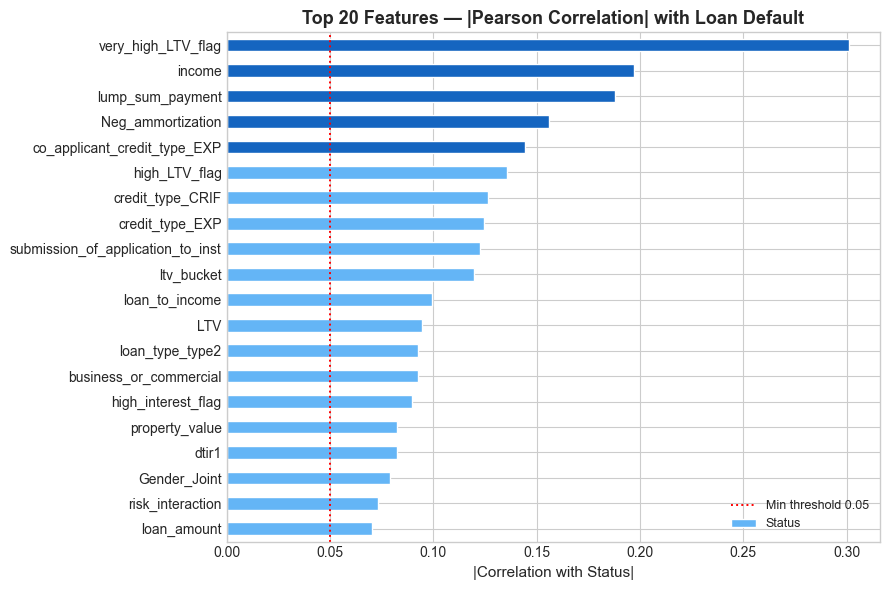

Top 10 correlated features:
very_high_LTV_flag                   0.301116
income                               0.197170
lump_sum_payment                     0.187752
Neg_ammortization                    0.155834
co_applicant_credit_type_EXP         0.144236
high_LTV_flag                        0.135475
credit_type_CRIF                     0.126335
credit_type_EXP                      0.124655
submission_of_application_to_inst    0.122413
ltv_bucket                           0.119498


In [12]:
corr_target = (
    df.corr()[TARGET_COL]
      .drop(TARGET_COL)
      .abs()
      .sort_values(ascending=False)
)
top20 = corr_target.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#1565C0" if i < 5 else "#64B5F6" for i in range(len(top20))]
top20.sort_values().plot(kind="barh", ax=ax, color=colors[::-1], edgecolor="white")
ax.axvline(0.05, color="red", linestyle=":", lw=1.4, label="Min threshold 0.05")
ax.set_title("Top 20 Features — |Pearson Correlation| with Loan Default",
             fontsize=13, fontweight="bold")
ax.set_xlabel("|Correlation with Status|", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=140, bbox_inches="tight")
plt.show()

print("Top 10 correlated features:")
print(top20.head(10).to_string())

---
## Cell 5 — Stratified 60 / 20 / 20 Split

In [14]:
# Drop any leftover identifier columns
drop_if_present = ["index", "level_0", "ID"]
df.drop(columns=[c for c in drop_if_present if c in df.columns], inplace=True)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype("int32")
feature_names = list(X.columns)

# Free original df - X and y are all we need from here
del df
gc.collect()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED
)
del X_temp, y_temp
gc.collect()

print(f"{'Split':<8}  {'Records':>10}  {'Defaults':>10}  {'Rate':>8}")
print("-" * 44)
for label, ys in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{label:<8}  {len(ys):>10,}  {ys.sum():>10,}  {ys.mean()*100:>7.2f} %")
print(f"\nTotal features: {len(feature_names)}")

Split        Records    Defaults      Rate
--------------------------------------------
Train         89,201      21,983    24.64 %
Val           29,734       7,328    24.65 %
Test          29,734       7,328    24.65 %

Total features: 50


---
## Cell 6 — Class Imbalance Analysis

Class 0 (no default) : 67,218
Class 1 (default)    : 21,983
Imbalance ratio      : 3.06x
Computed weights     : {0: 0.6635, 1: 2.0289}

Strategy: class_weight='balanced' -- adjusts loss proportional to
inverse class frequency. Faster and sufficient for LR baseline.


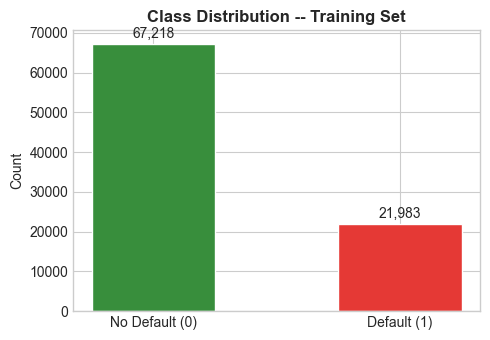

In [15]:
counts = y_train.value_counts().sort_index()
ratio  = counts[0] / counts[1]

cw_arr  = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
cw_dict = {0: round(float(cw_arr[0]), 4), 1: round(float(cw_arr[1]), 4)}

print(f"Class 0 (no default) : {counts[0]:,}")
print(f"Class 1 (default)    : {counts[1]:,}")
print(f"Imbalance ratio      : {ratio:.2f}x")
print(f"Computed weights     : {cw_dict}")
print()
print("Strategy: class_weight='balanced' -- adjusts loss proportional to")
print("inverse class frequency. Faster and sufficient for LR baseline.")

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(["No Default (0)", "Default (1)"],
              counts.values,
              color=["#388E3C", "#E53935"],
              edgecolor="white", width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            f"{v:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Class Distribution -- Training Set", fontsize=12, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Cell 7 — Build sklearn Pipeline

| Step | Component | Rationale |
|------|-----------|----------|
| 1 | `StandardScaler` | LR is scale-sensitive; normalise before fitting |
| 2 | `LogisticRegression` | L2 reg, lbfgs (efficient for high-dim dense data) |

In [16]:
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        C            = 1.0,        # L2 inverse strength; tuned in Cell 13
        penalty      = "l2",
        solver       = "lbfgs",    # memory-efficient; handles large N
        max_iter     = 1000,
        class_weight = "balanced", # automatically corrects imbalance
        random_state = RANDOM_SEED,
        n_jobs       = -1,
    )),
])

print("Pipeline:")
print(pipeline_lr)
print(f"\nInput features : {X_train.shape[1]}")
print(f"Training rows  : {X_train.shape[0]:,}")

Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, penalty='l2',
                                    random_state=42))])

Input features : 50
Training rows  : 89,201


---
## Cell 8 — 5-Fold Stratified Cross-Validation

In [17]:
print("Running 5-Fold Stratified CV on Training set ...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_results = {}
for metric in ["roc_auc", "f1", "precision", "recall"]:
    scores = cross_val_score(
        pipeline_lr, X_train, y_train,
        cv=cv, scoring=metric, n_jobs=-1
    )
    cv_results[metric] = scores
    print(f"  {metric:<12}  mean={scores.mean():.4f}  std={scores.std():.4f}")

cv_df = pd.DataFrame(
    cv_results,
    index=[f"Fold {i+1}" for i in range(5)]
)
cv_df.loc["Mean"] = cv_df.mean()
cv_df.loc["Std"]  = cv_df.std()
print("\n", cv_df.round(4).to_string())

cv_auc_mean = float(cv_results["roc_auc"].mean())
print(f"\nCV AUC-ROC  =  {cv_auc_mean:.4f}  +/-  {cv_results['roc_auc'].std():.4f}")

Running 5-Fold Stratified CV on Training set ...
  roc_auc       mean=0.8110  std=0.0023
  f1            mean=0.5835  std=0.0016
  precision     mean=0.5057  std=0.0030
  recall        mean=0.6895  std=0.0040

         roc_auc      f1  precision  recall
Fold 1   0.8067  0.5836     0.5042  0.6925
Fold 2   0.8117  0.5813     0.5048  0.6852
Fold 3   0.8127  0.5852     0.5111  0.6843
Fold 4   0.8108  0.5820     0.5024  0.6916
Fold 5   0.8131  0.5853     0.5061  0.6941
Mean     0.8110  0.5835     0.5057  0.6895
Std      0.0023  0.0016     0.0030  0.0040

CV AUC-ROC  =  0.8110  +/-  0.0023


---
## Cell 9 — Train on Full Training Set · Validation Evaluation

In [18]:
pipeline_lr.fit(X_train, y_train)
print("Model trained.")

y_val_prob = pipeline_lr.predict_proba(X_val)[:, 1]
y_val_pred = pipeline_lr.predict(X_val)

val_auc = roc_auc_score(y_val, y_val_prob)
val_ap  = average_precision_score(y_val, y_val_prob)
val_f1  = f1_score(y_val, y_val_pred)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"\n-- Validation (threshold = 0.50) -----------------------")
print(f"  AUC-ROC           :  {val_auc:.4f}")
print(f"  Average Precision :  {val_ap:.4f}")
print(f"  F1 Score          :  {val_f1:.4f}")
print(f"  Accuracy          :  {val_acc:.4f}")
print()
print(classification_report(y_val, y_val_pred,
                            target_names=["No Default", "Default"]))

if val_auc < 0.70:
    print("WARNING: AUC < 0.70 -- pipeline refinement initiated (Cells 12-13).")
else:
    print(f"Baseline AUC {val_auc:.4f} >= 0.70. Running C-grid for further optimisation.")

Model trained.

-- Validation (threshold = 0.50) -----------------------
  AUC-ROC           :  0.8071
  Average Precision :  0.6745
  F1 Score          :  0.5817
  Accuracy          :  0.7577

              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83     22406
     Default       0.51      0.68      0.58      7328

    accuracy                           0.76     29734
   macro avg       0.69      0.73      0.71     29734
weighted avg       0.79      0.76      0.77     29734

Baseline AUC 0.8071 >= 0.70. Running C-grid for further optimisation.


---
## Cell 10 — ROC Curve & Precision-Recall Curve

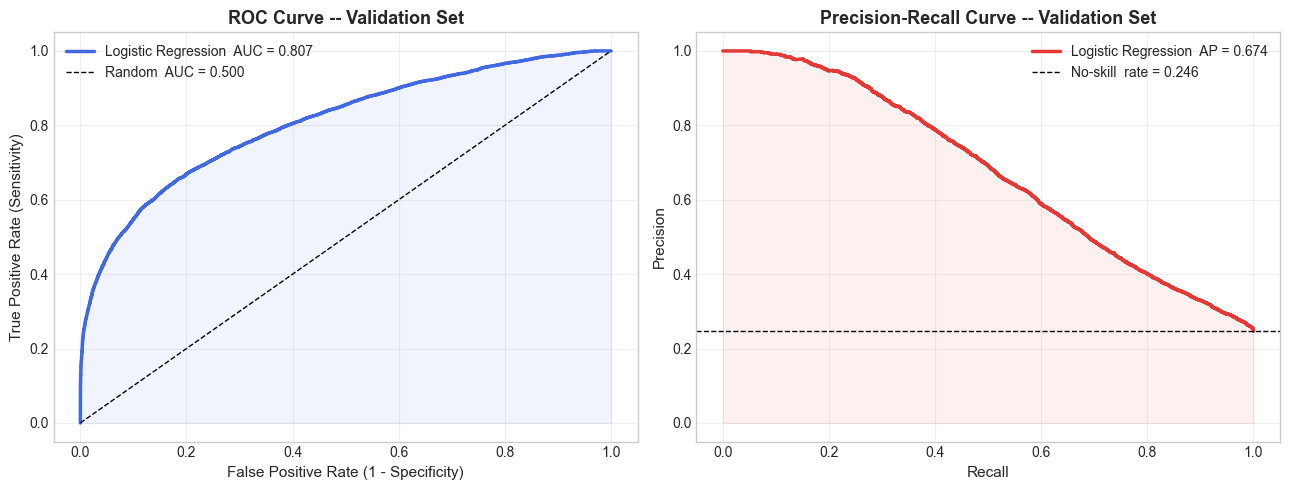

Baseline AUC-ROC: 0.8071


In [19]:
fpr, tpr, _   = roc_curve(y_val, y_val_prob)
prec, rec, _  = precision_recall_curve(y_val, y_val_prob)
baseline_rate = float(y_val.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color="royalblue", lw=2.5,
             label=f"Logistic Regression  AUC = {val_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random  AUC = 0.500")
axes[0].fill_between(fpr, tpr, alpha=0.07, color="royalblue")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[0].set_title("ROC Curve -- Validation Set", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(rec, prec, color="#E53935", lw=2.5,
             label=f"Logistic Regression  AP = {val_ap:.3f}")
axes[1].axhline(baseline_rate, color="k", linestyle="--", lw=1,
                label=f"No-skill  rate = {baseline_rate:.3f}")
axes[1].fill_between(rec, prec, alpha=0.07, color="#E53935")
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve -- Validation Set",
                  fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Baseline AUC-ROC: {val_auc:.4f}")

---
## Cell 11 — Confusion Matrix (default threshold 0.50)

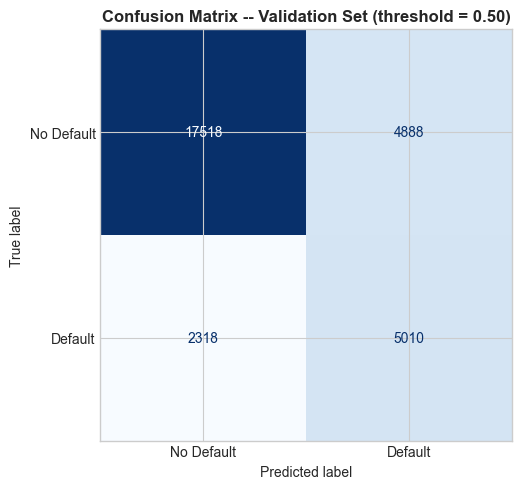

TN=17,518  FP=4,888  FN=2,318  TP=5,010
Sensitivity (Recall) : 0.6837
Specificity          : 0.7818
Precision            : 0.5062


In [20]:
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix -- Validation Set (threshold = 0.50)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Sensitivity (Recall) : {tp/(tp+fn):.4f}")
print(f"Specificity          : {tn/(tn+fp):.4f}")
print(f"Precision            : {tp/(tp+fp):.4f}")

---
## Cell 12 — Threshold Optimisation

In credit risk, a missed default (FN) is more costly than a false alarm (FP).  
We sweep thresholds and select the value that **maximises F1** on the validation set.

Optimal threshold (max F1) : 0.60
F1 at optimal threshold    : 0.5970

-- Validation @ threshold = 0.60 --------
              precision    recall  f1-score   support

  No Default       0.87      0.88      0.87     22406
     Default       0.61      0.58      0.60      7328

    accuracy                           0.81     29734
   macro avg       0.74      0.73      0.73     29734
weighted avg       0.80      0.81      0.80     29734



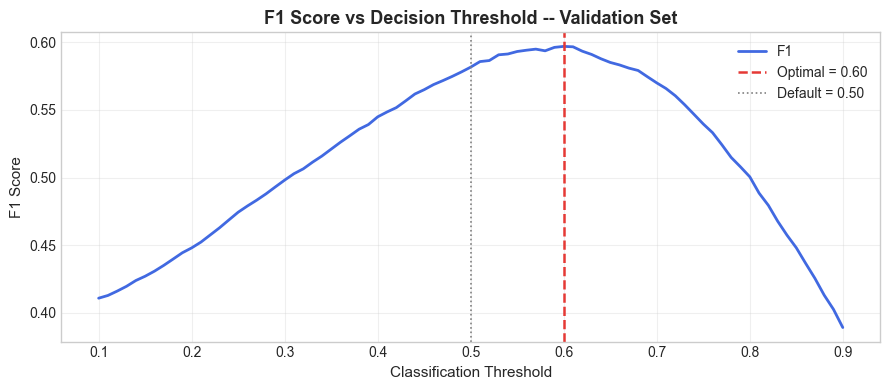

In [21]:
thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores  = [
    f1_score(y_val, (y_val_prob >= t).astype(int), zero_division=0)
    for t in thresholds
]

best_idx       = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
best_f1_val    = float(f1_scores[best_idx])

print(f"Optimal threshold (max F1) : {best_threshold:.2f}")
print(f"F1 at optimal threshold    : {best_f1_val:.4f}")

y_val_pred_opt = (y_val_prob >= best_threshold).astype(int)
print(f"\n-- Validation @ threshold = {best_threshold:.2f} --------")
print(classification_report(y_val, y_val_pred_opt,
                            target_names=["No Default", "Default"]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, color="royalblue", lw=2, label="F1")
ax.axvline(best_threshold, color="#E53935", linestyle="--", lw=1.8,
           label=f"Optimal = {best_threshold:.2f}")
ax.axvline(0.50, color="grey", linestyle=":", lw=1.2, label="Default = 0.50")
ax.set_xlabel("Classification Threshold", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score vs Decision Threshold -- Validation Set",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_optimisation.png", dpi=130, bbox_inches="tight")
plt.show()

---
## Cell 13 — Regularisation Refinement — C-Grid Search

If AUC is below 0.75 **or** we want the absolute best baseline, we grid-search C.  
3-fold CV is used here (vs 5-fold earlier) to keep runtime low while remaining statistically sound.

       C    CV AUC
--------------------
   0.001  0.8108
    0.01  0.8110
    0.05  0.8109
     0.1  0.8109
     0.5  0.8109
     1.0  0.8109  <-- current baseline
     2.0  0.8108
     5.0  0.8108
    10.0  0.8108
    50.0  0.8108

Best C = 0.01  (CV AUC = 0.8110)


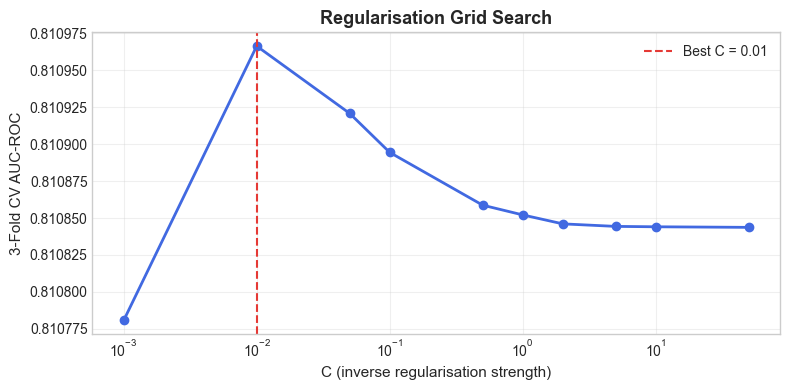

In [22]:
C_grid = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0]
C_aucs = []

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print(f"{'C':>8}  {'CV AUC':>8}")
print("-" * 20)
for C in C_grid:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(
            C=C, penalty="l2", solver="lbfgs",
            max_iter=1000, class_weight="balanced",
            random_state=RANDOM_SEED, n_jobs=-1,
        )),
    ])
    auc_c = cross_val_score(
        pipe, X_train, y_train,
        cv=cv3, scoring="roc_auc", n_jobs=-1
    ).mean()
    C_aucs.append(float(auc_c))
    marker = "  <-- current baseline" if C == 1.0 else ""
    print(f"{C:>8}  {auc_c:.4f}{marker}")

best_C     = C_grid[int(np.argmax(C_aucs))]
best_C_auc = max(C_aucs)
print(f"\nBest C = {best_C}  (CV AUC = {best_C_auc:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_grid, C_aucs, marker="o", color="royalblue", lw=2)
ax.axvline(best_C, color="#E53935", linestyle="--", lw=1.5,
           label=f"Best C = {best_C}")
ax.set_xlabel("C (inverse regularisation strength)", fontsize=11)
ax.set_ylabel("3-Fold CV AUC-ROC", fontsize=11)
ax.set_title("Regularisation Grid Search", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("c_grid_search.png", dpi=130, bbox_inches="tight")
plt.show()

---
## Cell 14 — Retrain with Best C · Refined Pipeline

In [23]:
pipeline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        C            = best_C,
        penalty      = "l2",
        solver       = "lbfgs",
        max_iter     = 1000,
        class_weight = "balanced",
        random_state = RANDOM_SEED,
        n_jobs       = -1,
    )),
])

pipeline_final.fit(X_train, y_train)

y_val_prob_f = pipeline_final.predict_proba(X_val)[:, 1]
y_val_pred_f = (y_val_prob_f >= best_threshold).astype(int)

final_val_auc = roc_auc_score(y_val, y_val_prob_f)
final_val_ap  = average_precision_score(y_val, y_val_prob_f)
final_val_f1  = f1_score(y_val, y_val_pred_f)
final_val_acc = accuracy_score(y_val, y_val_pred_f)

print(f"-- Refined Model  C={best_C}  threshold={best_threshold:.2f} --")
print(f"  AUC-ROC           :  {final_val_auc:.4f}")
print(f"  Average Precision :  {final_val_ap:.4f}")
print(f"  F1 Score          :  {final_val_f1:.4f}")
print(f"  Accuracy          :  {final_val_acc:.4f}")
print()
print(classification_report(y_val, y_val_pred_f,
                            target_names=["No Default", "Default"]))
delta_auc = final_val_auc - val_auc
print(f"AUC delta from C-tuning : {delta_auc:+.4f}")

-- Refined Model  C=0.01  threshold=0.60 --
  AUC-ROC           :  0.8071
  Average Precision :  0.6735
  F1 Score          :  0.5970
  Accuracy          :  0.8069

              precision    recall  f1-score   support

  No Default       0.87      0.88      0.87     22406
     Default       0.61      0.58      0.60      7328

    accuracy                           0.81     29734
   macro avg       0.74      0.73      0.74     29734
weighted avg       0.80      0.81      0.81     29734

AUC delta from C-tuning : -0.0000


---
## Cell 15 — Feature Importance (Standardised Coefficients)

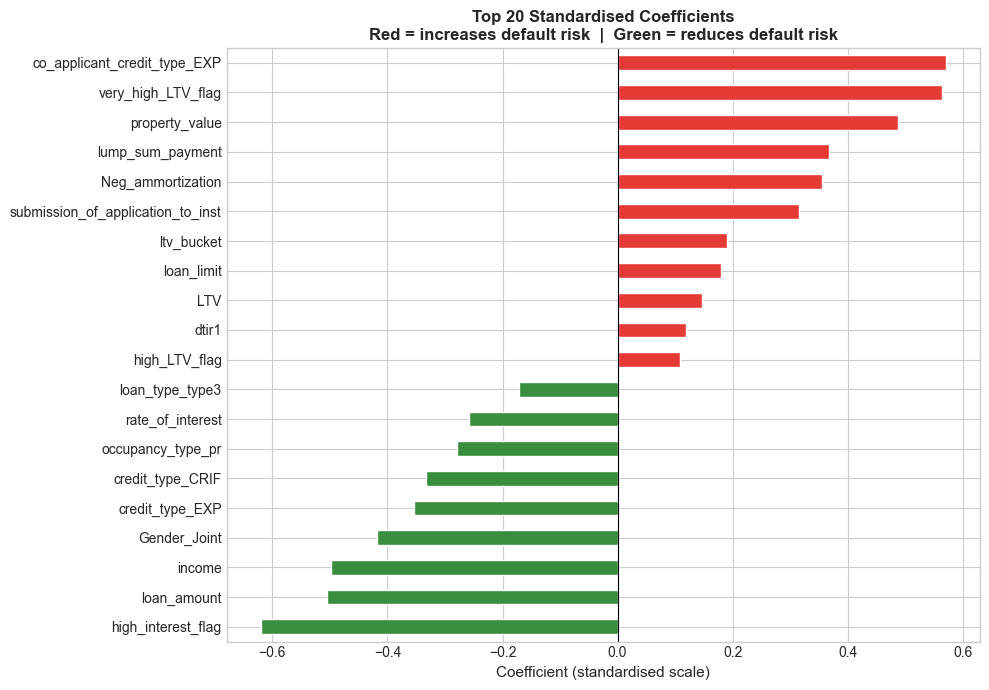

Top 5 risk-INCREASING features:
co_applicant_credit_type_EXP    0.570546
very_high_LTV_flag              0.564075
property_value                  0.488250
lump_sum_payment                0.368264
Neg_ammortization               0.355314

Top 5 risk-DECREASING features:
high_interest_flag   -0.620095
loan_amount          -0.505665
income               -0.497860
Gender_Joint         -0.418063
credit_type_EXP      -0.354182


In [24]:
coef_vals   = pipeline_final.named_steps["model"].coef_[0]
coef_series = pd.Series(coef_vals, index=feature_names)

# Top 20 by absolute value
top20_idx         = coef_series.abs().sort_values(ascending=False).head(20).index
top20_coef_signed = coef_series[top20_idx].sort_values()

colors = ["#E53935" if v > 0 else "#388E3C" for v in top20_coef_signed.values]

fig, ax = plt.subplots(figsize=(10, 7))
top20_coef_signed.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(
    "Top 20 Standardised Coefficients\n"
    "Red = increases default risk  |  Green = reduces default risk",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Coefficient (standardised scale)", fontsize=11)
plt.tight_layout()
plt.savefig("feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 risk-INCREASING features:")
print(coef_series.sort_values(ascending=False).head(5).to_string())
print("\nTop 5 risk-DECREASING features:")
print(coef_series.sort_values().head(5).to_string())

---
## Cell 16 — Final Holdout Test Evaluation

  FINAL HOLDOUT TEST RESULTS
  AUC-ROC            :  0.8090
  Average Precision  :  0.6728
  F1 Score           :  0.5968
  Accuracy           :  0.8061

              precision    recall  f1-score   support

  No Default       0.87      0.88      0.87     22406
     Default       0.61      0.58      0.60      7328

    accuracy                           0.81     29734
   macro avg       0.74      0.73      0.73     29734
weighted avg       0.80      0.81      0.80     29734



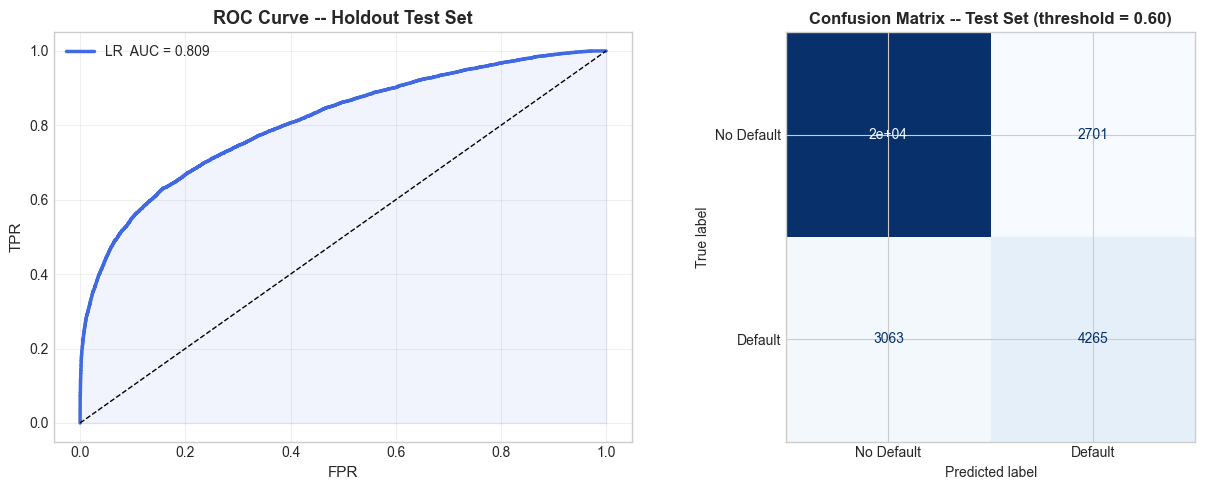

In [25]:
y_test_prob = pipeline_final.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
test_ap  = average_precision_score(y_test, y_test_prob)
test_f1  = f1_score(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

print("=" * 50)
print("  FINAL HOLDOUT TEST RESULTS")
print("=" * 50)
print(f"  AUC-ROC            :  {test_auc:.4f}")
print(f"  Average Precision  :  {test_ap:.4f}")
print(f"  F1 Score           :  {test_f1:.4f}")
print(f"  Accuracy           :  {test_acc:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_test_pred,
                            target_names=["No Default", "Default"]))

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_t, tpr_t, color="royalblue", lw=2.5,
             label=f"LR  AUC = {test_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].fill_between(fpr_t, tpr_t, alpha=0.07, color="royalblue")
axes[0].set_xlabel("FPR", fontsize=11)
axes[0].set_ylabel("TPR", fontsize=11)
axes[0].set_title("ROC Curve -- Holdout Test Set",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["No Default", "Default"]
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(
    f"Confusion Matrix -- Test Set (threshold = {best_threshold:.2f})",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("final_test_results.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 17 — Persist Model Artefact

In [26]:
artefact = {
    "pipeline"       : pipeline_final,
    "feature_names"  : feature_names,
    "best_C"         : best_C,
    "best_threshold" : best_threshold,
    "cv_auc"         : cv_auc_mean,
    "val_auc"        : float(final_val_auc),
    "test_auc"       : float(test_auc),
    "val_f1"         : float(final_val_f1),
    "test_f1"        : float(test_f1),
}

with open(MODEL_PATH, "wb") as fh:
    pickle.dump(artefact, fh)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Model saved  ->  {MODEL_PATH}  ({size_kb:.1f} KB)")

# Reload sanity check
with open(MODEL_PATH, "rb") as fh:
    loaded = pickle.load(fh)
sanity_auc = roc_auc_score(
    y_test[:200],
    loaded["pipeline"].predict_proba(X_test[:200])[:, 1]
)
print(f"Reload sanity AUC (first 200 test rows): {sanity_auc:.4f}")

Model saved  ->  lr_baseline.pkl  (3.8 KB)
Reload sanity AUC (first 200 test rows): 0.8203


---
## Cell 18 — Write Results Back to SQLite

In [27]:
results_row = pd.DataFrame([{
    "model_name"     : "LogisticRegression_Baseline",
    "best_C"         : best_C,
    "best_threshold" : round(best_threshold, 3),
    "cv_auc"         : round(cv_auc_mean, 4),
    "val_auc"        : round(float(final_val_auc), 4),
    "test_auc"       : round(float(test_auc), 4),
    "val_f1"         : round(float(final_val_f1), 4),
    "test_f1"        : round(float(test_f1), 4),
    "val_ap"         : round(float(final_val_ap), 4),
    "test_ap"        : round(float(test_ap), 4),
    "train_rows"     : int(len(X_train)),
    "feature_count"  : int(len(feature_names)),
    "model_path"     : MODEL_PATH,
}])

coef_df = pd.DataFrame({
    "feature"    : feature_names,
    "coefficient": pipeline_final.named_steps["model"].coef_[0].tolist(),
}).sort_values("coefficient", ascending=False)

conn = sqlite3.connect(DB_PATH)
results_row.to_sql("model_results",       conn, if_exists="replace", index=False)
coef_df.to_sql("feature_coefficients",   conn, if_exists="replace", index=False)
conn.close()

print(f"Results written to  {DB_PATH}")
print("  Tables: model_results, feature_coefficients")
print()
print(results_row.T.to_string(header=False))

Results written to  loans.db
  Tables: model_results, feature_coefficients

model_name      LogisticRegression_Baseline
best_C                                 0.01
best_threshold                          0.6
cv_auc                                0.811
val_auc                              0.8071
test_auc                              0.809
val_f1                                0.597
test_f1                              0.5968
val_ap                               0.6735
test_ap                              0.6728
train_rows                            89201
feature_count                            50
model_path                  lr_baseline.pkl


---
## Cell 19 — Milestone 3 Summary

In [29]:
border = "=" * 62
print(border)
print("  MILESTONE 3 SUMMARY -- LOGISTIC REGRESSION BASELINE (LEAKAGE-CORRECTED)")
print(border)
print()
print("  LEAKAGE FIX")
print("  Removed : Upfront_charges, log_Upfront_charges, Interest_rate_spread")
print("  Reason  : Post-outcome proxies causing AUC ~1.0")
print()
print("  FEATURE ENGINEERING PIPELINE")
print("  A. Risk flags       high_LTV / low_credit / high_dti")
print("  B. Interactions     risk_interaction, credit_dti,")
print("                      ltv_dti, triple_risk_flag")
print("  C. Ratios           loan_to_income")
print("  D. Log transforms   NONE (log_Upfront_charges excluded — leakage)")
print("  E. Ordinal buckets  credit_bucket (0-4), ltv_bucket (0-4)")
print()
print("  MODEL CONFIGURATION")
print("  Algorithm        : LogisticRegression (sklearn pipeline)")
print("  Regularisation   : L2")
print(f" Best C            : {best_C}")
print("  Imbalance        : class_weight='balanced'")
print("  Scaler           : StandardScaler")
print(f"  Threshold        : {best_threshold:.2f}  (F1-optimal on val set)")
print()
print("  EVALUATION RESULTS")
print(f"  5-Fold CV AUC    : {cv_auc_mean:.4f}")
print(f"  Validation AUC   : {final_val_auc:.4f}")
print(f"  Test AUC-ROC     : {test_auc:.4f}   <-- primary baseline metric")
print(f"  Test F1 Score    : {test_f1:.4f}")
print()
print("  OUTPUTS")
print(f"  {MODEL_PATH:<30} pickled model artefact")
print(f"  {DB_PATH:<30} model_results + feature_coefficients")
print("  *.png                          ROC, PR, CM, threshold, coef plots")
print()

  MILESTONE 3 SUMMARY -- LOGISTIC REGRESSION BASELINE (LEAKAGE-CORRECTED)

  LEAKAGE FIX
  Removed : Upfront_charges, log_Upfront_charges, Interest_rate_spread
  Reason  : Post-outcome proxies causing AUC ~1.0

  FEATURE ENGINEERING PIPELINE
  A. Risk flags       high_LTV / low_credit / high_dti
  B. Interactions     risk_interaction, credit_dti,
                      ltv_dti, triple_risk_flag
  C. Ratios           loan_to_income
  D. Log transforms   NONE (log_Upfront_charges excluded — leakage)
  E. Ordinal buckets  credit_bucket (0-4), ltv_bucket (0-4)

  MODEL CONFIGURATION
  Algorithm        : LogisticRegression (sklearn pipeline)
  Regularisation   : L2
 Best C            : 0.01
  Imbalance        : class_weight='balanced'
  Scaler           : StandardScaler
  Threshold        : 0.60  (F1-optimal on val set)

  EVALUATION RESULTS
  5-Fold CV AUC    : 0.8110
  Validation AUC   : 0.8071
  Test AUC-ROC     : 0.8090   <-- primary baseline metric
  Test F1 Score    : 0.5968

  OUTPUTS

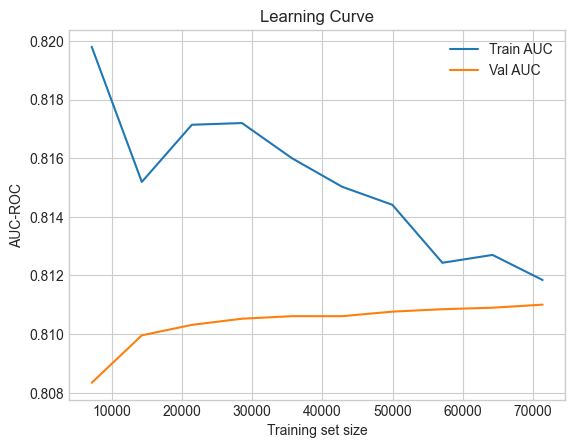

In [34]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_lr, X_train, y_train,
    cv=5, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train AUC")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Val AUC")
plt.xlabel("Training set size")
plt.ylabel("AUC-ROC")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [36]:
train_auc = roc_auc_score(y_train, pipeline_final.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  pipeline_final.predict_proba(X_test)[:, 1])

print(f"Train AUC : {train_auc:.4f}")
print(f"Test AUC  : {test_auc:.4f}")
print(f"Gap       : {train_auc - test_auc:.4f}")

Train AUC : 0.8118
Test AUC  : 0.8090
Gap       : 0.0028
